# 032 多维梯度下降与尺度

## Goal
同一步长为什么在狭长谷里折返？本Notebook先逐样本复算两轮，再真正执行整批NumPy更新，比较Hessian谱、训练标准化、共同误差和失败案例。所有数据是确定性原创合成数据，不进行真实任务效果评价。

固定教学基准：四角训练数据，目标SSE/(2n)，残差预测减观测。标准化只fit训练集；全量输入字节检查在任何数字或图像输出之前。若修改数据/配置，请用通用脚本，或复制本Notebook并同步修改手算与说明。

## Setup
从本讲目录打开，选择Python 3内核，重启后从第一格顺序执行。此格必须先核验完整默认输入与全部类型/字段，之后才输出版本。浏览器Jupyter、conda创建和外部进程内核传输未在制作环境实测；保存输出来自真实InProcessKernel的新进程顺序执行。

In [1]:
from pathlib import Path
import io, math, sys
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display
from fractions import Fraction as F
import experiment as e
D, query, config = e.check_notebook_baseline()
print("Python", sys.version.split()[0], "NumPy", np.__version__, "Matplotlib", matplotlib.__version__)
plt.rcParams.update({"font.family":"DejaVu Sans", "font.size":10, "axes.grid":True, "grid.alpha":.2})
colors = ["#2459a6", "#dc6539", "#19806e", "#9b5cad", "#b78b16", "#c13e51"]
def show(fig):
    fig.tight_layout(pad=1.1)
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", dpi=145, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))
    plt.close(fig)
X, y = D["hand"]["X"], D["hand"]["y"]
A = e.design(X)

Python 3.12.14 NumPy 2.3.5 Matplotlib 3.10.8


## Steps
### 1. 检查数据和每个形状
A列次序是截距、x1、x2。y必须是(n,)，不能让广播生成(n,n)残差。闭式参照使用实际存储的二进制值进行精确有理数消元；lstsq另外核对。

In [2]:
print("A shape", A.shape, "y shape", y.shape)
print(np.column_stack([A, y]))
reference = e.exact_reference(A, y)
print("Exact reference:", reference)
lstsq_beta, _, rank, _ = np.linalg.lstsq(A, y, rcond=None)
print("lstsq beta:", lstsq_beta, "rank:", rank)
print("Recomputed SSE:", np.sum((A @ lstsq_beta - y)**2))
e.require(np.allclose(lstsq_beta, reference["theta"], atol=1e-12), "reference mismatch")

A shape (4, 3) y shape (4,)
[[  1.   -1.  -10.   -1.5]
 [  1.   -1.   10.    3.5]
 [  1.    1.  -10.    1.5]
 [  1.    1.   10.    8.5]]
Exact reference: {'rank_exact': 3, 'hessian_exact': [['1', '0', '0'], ['0', '1', '0'], ['0', '0', '100']], 'theta': [3.0, 2.0, 0.3], 'theta_exact': ['3', '2', '3/10'], 'loss': 0.125, 'loss_exact': '1/8'}
lstsq beta: [3.  2.  0.3] rank: 3
Recomputed SSE: 1.0


### 2. 从Fraction逐条复算前两次更新
这格不调用轨迹求解器：直接对每条样本求预测、残差、r²/(2n)、rA/n，累加后同步更新。t=2额外显示更新后的前向与导数，避免只核对最终loss。

In [3]:
FA = [[F(float(v)) for v in row] for row in A]
Fy = [F(float(v)) for v in y]
beta_f = [F(0)]*3
for t in range(3):
    pred = [sum((a*b for a,b in zip(row,beta_f)), F()) for row in FA]
    residual = [p-yi for p,yi in zip(pred,Fy)]
    sample_loss = [r*r/8 for r in residual]
    contributions = [[a*r/4 for a in row] for row,r in zip(FA,residual)]
    gradient = [sum(row[j] for row in contributions) for j in range(3)]
    print("t =", t, "beta =", list(map(str,beta_f)))
    for i in range(4):
        print(i+1, "prediction", str(pred[i]), "residual", str(residual[i]),
              "sample loss", str(sample_loss[i]), "gradient contribution", list(map(str,contributions[i])))
    print("J =", str(sum(sample_loss)), "gradient =", list(map(str,gradient)))
    beta_f = [b-F(1,64)*g for b,g in zip(beta_f,gradient)]

t = 0 beta = ['0', '0', '0']
1 prediction 0 residual 3/2 sample loss 9/32 gradient contribution ['3/8', '-3/8', '-15/4']
2 prediction 0 residual -7/2 sample loss 49/32 gradient contribution ['-7/8', '7/8', '-35/4']
3 prediction 0 residual -3/2 sample loss 9/32 gradient contribution ['-3/8', '-3/8', '15/4']
4 prediction 0 residual -17/2 sample loss 289/32 gradient contribution ['-17/8', '-17/8', '-85/4']
J = 89/8 gradient = ['-3', '-2', '-30']
t = 1 beta = ['3/64', '1/32', '15/32']
1 prediction -299/64 residual -203/64 sample loss 41209/32768 gradient contribution ['-203/256', '203/256', '1015/128']
2 prediction 301/64 residual 77/64 sample loss 5929/32768 gradient contribution ['77/256', '-77/256', '385/128']
3 prediction -295/64 residual -391/64 sample loss 152881/32768 gradient contribution ['-391/256', '-391/256', '1955/128']
4 prediction 305/64 residual -239/64 sample loss 57121/32768 gradient contribution ['-239/256', '-239/256', '-1195/128']
J = 64285/8192 gradient = ['-189/64', 

### 3. 图1 样本贡献与新前向
左侧是第0轮各样本的三个导数贡献，黑星是相加结果。右侧显示更新后必须重新计算预测。

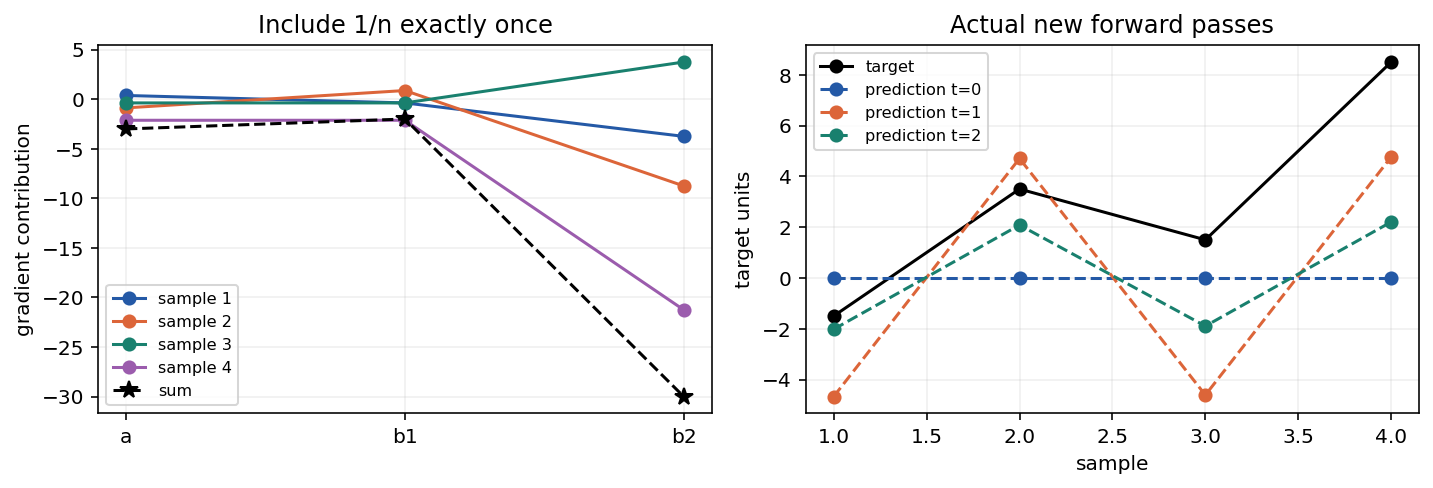

In [4]:
short_spec = {"initial":[0,0,0], "learning_rate":1/64, "gradient_tolerance":0,
              "max_steps":2, "parameter_limit":1e6}
short = e.trace_path(A,y,short_spec)
fig, axes = plt.subplots(1,2,figsize=(10,3.5))
parts = A * np.array(short["history"][0]["residual"])[:,None] / len(y)
for i in range(4):
    axes[0].plot(range(3),parts[i],"o-",label=f"sample {i+1}",color=colors[i])
axes[0].plot(range(3),parts.sum(axis=0),"k*--",label="sum",ms=9)
axes[0].set(xticks=range(3),xticklabels=["a","b1","b2"],ylabel="gradient contribution",title="Include 1/n exactly once")
axes[0].legend(fontsize=8)
axes[1].plot(range(1,5),y,"ko-",label="target")
for t in range(3):
    axes[1].plot(range(1,5),short["history"][t]["prediction"],"o--",label=f"prediction t={t}",color=colors[t])
axes[1].set(xlabel="sample",ylabel="target units",title="Actual new forward passes")
axes[1].legend(fontsize=8)
show(fig)

### 4. 最小核心更新代码
这里直接写出整批GD，不调用任何优化器。验证shape和输入后，下面循环展示“同一旧参数→全部残差→全部梯度→新参数”。生产脚本另加数值范围、停止状态与输出保护。

In [5]:
beta = np.zeros(3)
for t in range(2):
    prediction = A @ beta
    residual = prediction - y
    gradient = A.T @ residual / len(y)
    beta_next = beta - (1/64)*gradient
    print("update", t+1, "old", beta, "gradient", gradient, "new", beta_next)
    beta = beta_next
np.testing.assert_allclose(beta, [381/4096,127/2048,105/512], atol=0, rtol=0)
R = e.compile_report(D, query, config)
for name, run in R["paths"].items():
    last=run["history"][-1]
    print(name, run["status"], "updates", run["updates_completed"],
          "raw coefficient error", f"{last['parameter_error_raw']:.6g}")

update 1 old [0. 0. 0.] gradient [ -3.  -2. -30.] new [0.046875 0.03125  0.46875 ]
update 2 old [0.046875 0.03125  0.46875 ] gradient [-2.953125 -1.96875  16.875   ] new [0.09301758 0.06201172 0.20507812]


raw_dyadic gradient_tolerance_met updates 1252 raw coefficient error 9.86307e-09
raw_minimax gradient_tolerance_met updates 1092 raw coefficient error 1.18348e-09
scaled_same_rate gradient_tolerance_met updates 1268 raw coefficient error 7.69271e-09
scaled_half gradient_tolerance_met updates 29 raw coefficient error 6.73907e-09
scaled_one gradient_tolerance_met updates 1 raw coefficient error 0
raw_unstable parameter_limit_reached updates 19 raw coefficient error 497669


### 5. 图2 原坐标中的之字形
只投影b1与b2；截距也在真实更新，只未画在此二维投影。右图是误差序列，说明折返幅度在减小。

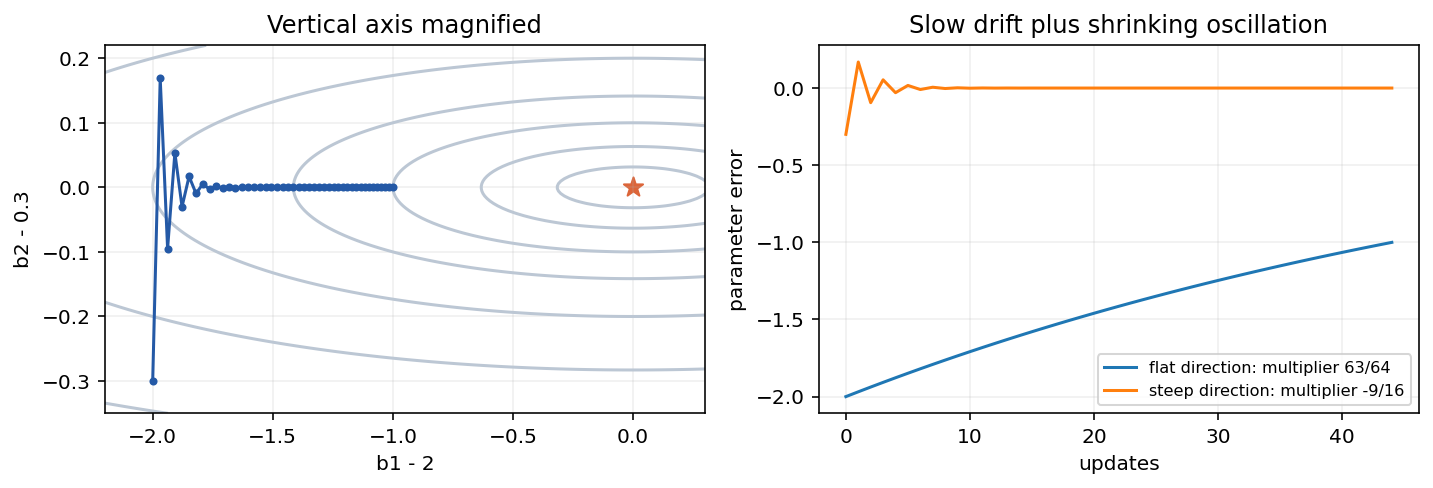

In [6]:
h = R["paths"]["raw_dyadic"]["history"][:45]
b = np.array([s["theta_raw"] for s in h])
fig,axes=plt.subplots(1,2,figsize=(10,3.5))
u,v=np.meshgrid(np.linspace(-2.2,.3,200),np.linspace(-.35,.22,150))
axes[0].contour(u,v,.5*u*u+50*v*v,levels=[.05,.2,.5,1,2,4,8],colors="#bcc7d4")
axes[0].plot(b[:,1]-2,b[:,2]-.3,"o-",ms=3,color=colors[0])
axes[0].scatter([0],[0],marker="*",s=100,color=colors[1])
axes[0].set(xlabel="b1 - 2",ylabel="b2 - 0.3",title="Vertical axis magnified")
axes[1].plot(b[:,1]-2,label="flat direction: multiplier 63/64")
axes[1].plot(b[:,2]-.3,label="steep direction: multiplier -9/16")
axes[1].set(xlabel="updates",ylabel="parameter error",title="Slow drift plus shrinking oscillation")
axes[1].legend(fontsize=8)
show(fig)

### 6. 图3 用Hessian谱解释稳定性
原谱(1,1,100)，标准化谱(1,1,1)。折返不必意味着loss上升；每个特征方向的绝对倍率小于1才是二次问题的关键。

raw H: [[  1.   0.   0.]
 [  0.   1.   0.]
 [  0.   0. 100.]] condition: 100.0
scaled H: [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]] condition: 1.0


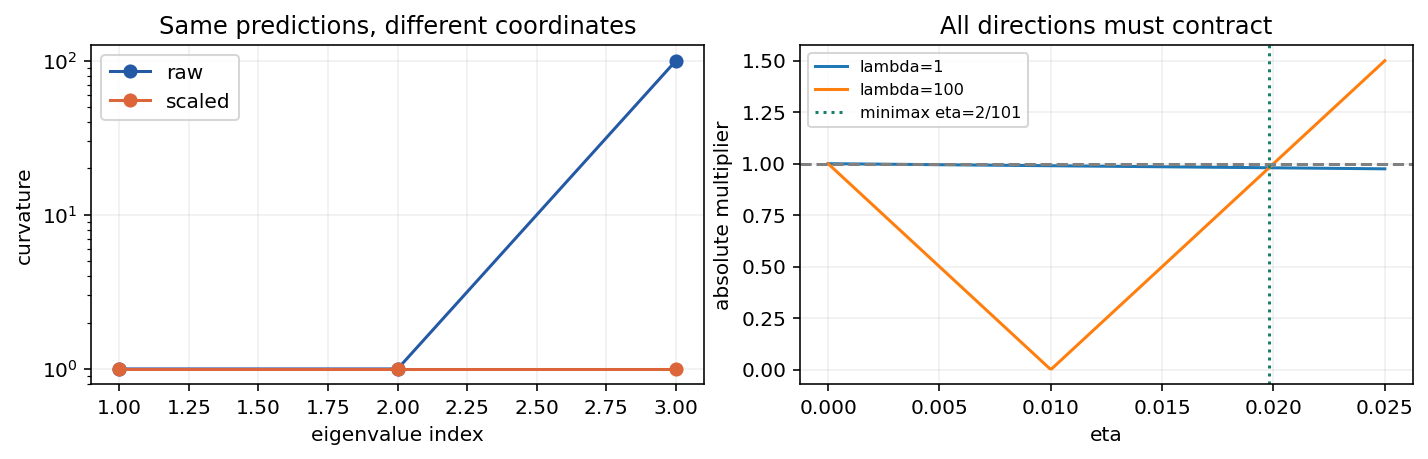

In [7]:
raw_geo=R["cases"]["hand"]["raw"]
scaled_geo=R["cases"]["hand"]["scaled"]
print("raw H:", np.array(raw_geo["hessian"]), "condition:",raw_geo["condition_number"])
print("scaled H:", np.array(scaled_geo["hessian"]), "condition:",scaled_geo["condition_number"])
fig,axes=plt.subplots(1,2,figsize=(10,3.3))
for geo,label,color in [(raw_geo,"raw",colors[0]),(scaled_geo,"scaled",colors[1])]:
    axes[0].plot([1,2,3],geo["eigenvalues"],"o-",label=label,color=color)
axes[0].set(yscale="log",xlabel="eigenvalue index",ylabel="curvature",title="Same predictions, different coordinates")
axes[0].legend()
etas=np.linspace(0,.025,300)
axes[1].plot(etas,np.abs(1-etas),label="lambda=1")
axes[1].plot(etas,np.abs(1-100*etas),label="lambda=100")
axes[1].axhline(1,color="gray",ls="--")
axes[1].axvline(2/101,color=colors[2],ls=":",label="minimax eta=2/101")
axes[1].set(xlabel="eta",ylabel="absolute multiplier",title="All directions must contract")
axes[1].legend(fontsize=8)
show(fig)

### 7. 图4 训练标准化与映回
标准化仅用train fit，theta的第二斜率等于原b2的10倍。图中每条路径均映回原坐标后比较，旧学习率不自动获得加速。

training scaler: {'mean': [0.0, 0.0], 'mean_exact': ['0', '0'], 'scale': [1.0, 10.0], 'zero_variance': [False, False]}
scaled optimum: ['3', '2', '3']


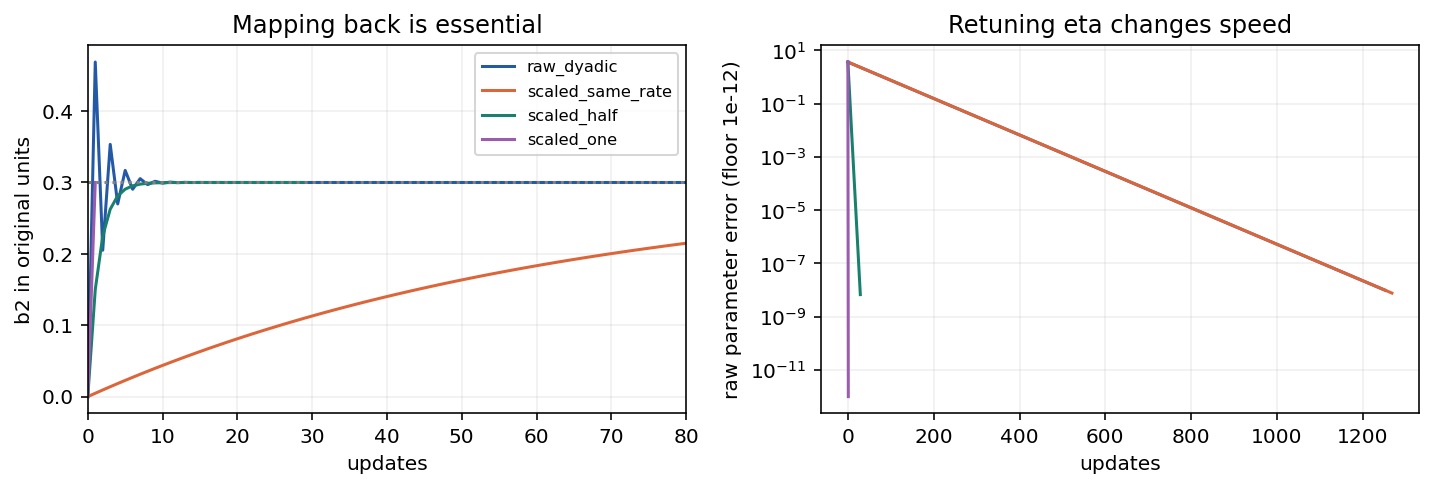

In [8]:
scaler=e.fit_scaler(X)
Z=e.transform(X,scaler)
print("training scaler:",scaler)
print("scaled optimum:",e.exact_reference(e.design(Z),y)["theta_exact"])
fig,axes=plt.subplots(1,2,figsize=(10,3.5))
for name,color in zip(["raw_dyadic","scaled_same_rate","scaled_half","scaled_one"],colors):
    run=R["paths"][name]
    states=run["history"]
    axes[0].plot([s["iteration"] for s in states],[s["theta_raw"][2] for s in states],label=name,color=color)
    axes[1].semilogy([s["iteration"] for s in states],[max(s["parameter_error_raw"],1e-12) for s in states],label=name,color=color)
axes[0].axhline(.3,color="gray",ls=":")
axes[0].set(xlabel="updates",ylabel="b2 in original units",xlim=(0,80),title="Mapping back is essential")
axes[1].set(xlabel="updates",ylabel="raw parameter error (floor 1e-12)",title="Retuning eta changes speed")
axes[0].legend(fontsize=8)
show(fig)

### 8. 图5 同一把误差尺
工作坐标梯度阈值相同并不代表同一精度。用共同的训练预测距离E_pred，以及直接计算的二次差核对。raw_unstable未达标，19次更新只是保护停止的位置。

raw_dyadic first common prediction tolerance: 1252 final raw gradient: 9.863071445473756e-09
raw_minimax first common prediction tolerance: 999 final raw gradient: 9.883892774596593e-09
scaled_same_rate first common prediction tolerance: 1268 final raw gradient: 6.424585695059106e-08
scaled_half first common prediction tolerance: 29 final raw gradient: 5.6281479805640753e-08
scaled_one first common prediction tolerance: 1 final raw gradient: 0.0
raw_unstable first common prediction tolerance: None final raw gradient: 49766947.99703853


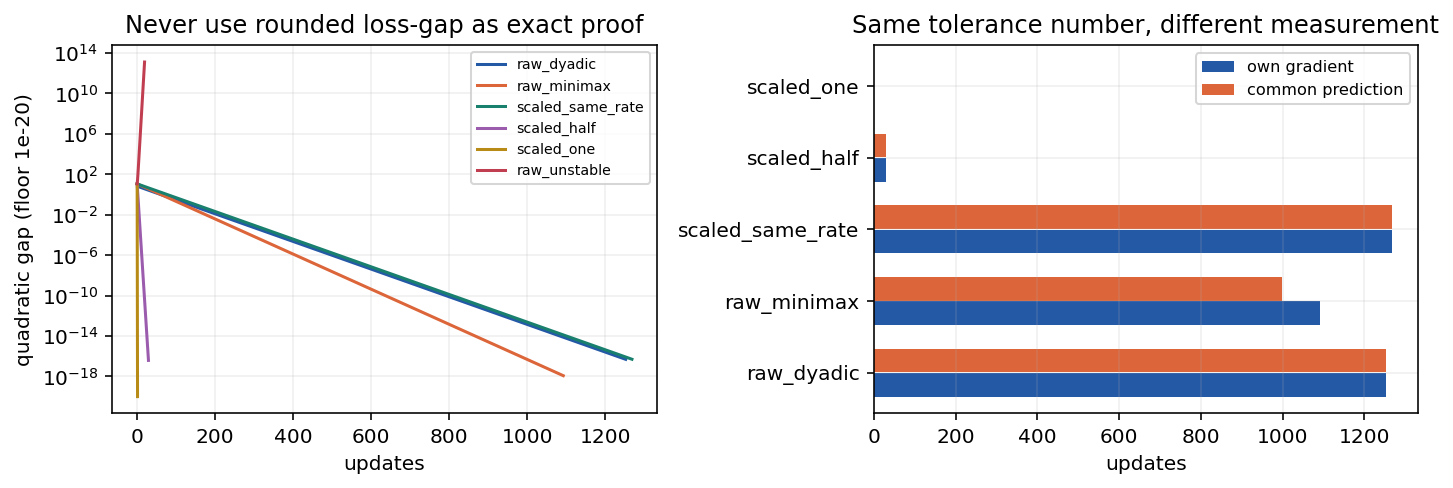

In [9]:
common=[]
for name,run in R["paths"].items():
    first=next((s["iteration"] for s in run["history"] if math.sqrt(2*s["quadratic_gap_raw"])<=1e-8),None)
    common.append(first)
    print(name,"first common prediction tolerance:",first,"final raw gradient:",run["history"][-1]["gradient_norm_raw"])
fig,axes=plt.subplots(1,2,figsize=(10,3.5))
for (name,run),color in zip(R["paths"].items(),colors):
    axes[0].semilogy([s["iteration"] for s in run["history"]],[max(s["quadratic_gap_raw"],1e-20) for s in run["history"]],label=name,color=color)
axes[0].set(xlabel="updates",ylabel="quadratic gap (floor 1e-20)",title="Never use rounded loss-gap as exact proof")
axes[0].legend(fontsize=7)
names=list(R["paths"])[:-1];positions=np.arange(5)
axes[1].barh(positions-.17,[R["paths"][n]["updates_completed"] for n in names],height=.33,label="own gradient",color=colors[0])
axes[1].barh(positions+.17,common[:-1],height=.33,label="common prediction",color=colors[1])
axes[1].set(yticks=positions,yticklabels=names,xlabel="updates",title="Same tolerance number, different measurement")
axes[1].legend(fontsize=8)
show(fig)

### 9. 图6 相同方差不代表没有相关性
correlated特征为(u,u+v/8)，标准化后ρ=8/sqrt(65)。constant列虽然除数置1，仍没有增加训练信息。

correlation: 0.9922778767136677 theoretical scaled kappa: 257.9961239727798
correlated raw numerical eigenvalues [0.007781982887522021, 1.0, 2.007843017112478] exact rank 3
constant raw numerical eigenvalues [-1.1102230246251565e-16, 1.0, 50.0] exact rank 2


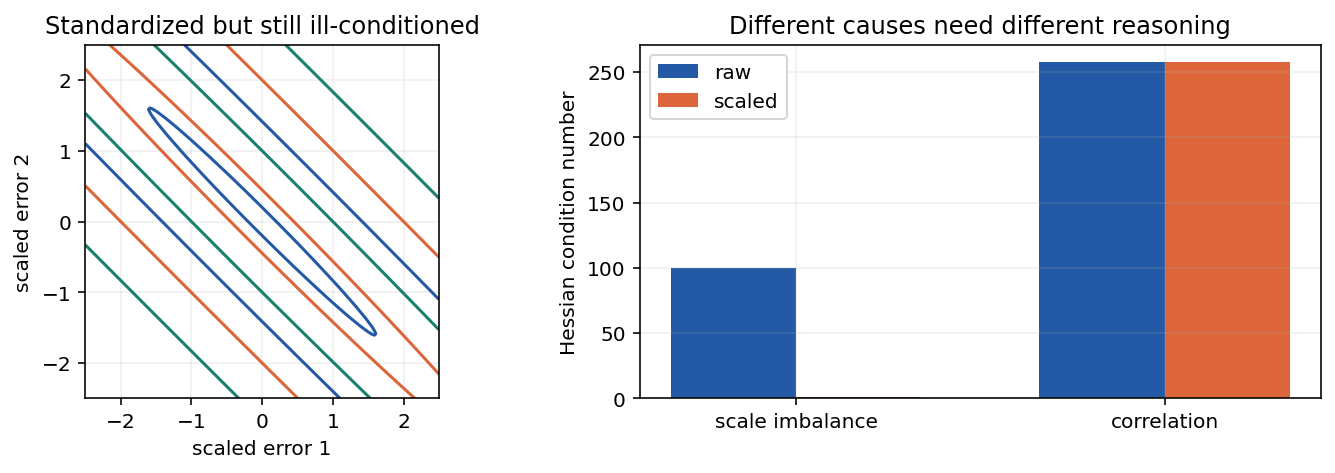

In [10]:
rho=8/np.sqrt(65)
print("correlation:",rho,"theoretical scaled kappa:",(1+rho)/(1-rho))
for name in ("correlated","constant"):
    print(name,"raw numerical eigenvalues",R["cases"][name]["raw"]["eigenvalues"],
          "exact rank",R["cases"][name]["raw"]["reference"]["rank_exact"])
fig,axes=plt.subplots(1,2,figsize=(10,3.4))
u,v=np.meshgrid(np.linspace(-2.5,2.5,160),np.linspace(-2.5,2.5,160))
axes[0].contour(u,v,.5*(u*u+2*rho*u*v+v*v),levels=[.02,.1,.5,1,2,4],colors=colors[:3])
axes[0].set(xlabel="scaled error 1",ylabel="scaled error 2",title="Standardized but still ill-conditioned")
axes[0].set_aspect("equal")
for j,name in enumerate(("hand","correlated")):
    axes[1].bar(j-.17,R["cases"][name]["raw"]["condition_number"],width=.34,color=colors[0],label="raw" if j==0 else None)
    axes[1].bar(j+.17,R["cases"][name]["scaled"]["condition_number"],width=.34,color=colors[1],label="scaled" if j==0 else None)
axes[1].set(xticks=[0,1],xticklabels=["scale imbalance","correlation"],ylabel="Hessian condition number",title="Different causes need different reasoning")
axes[1].legend()
show(fig)

### 10. 图7 仅用训练统计处理查询
左图比较正确train-only与故意错误的train+query拟合统计。右图显示训练常数列。错误流程只在临时变量中作为反例，不替换正式结果。

correct query transform: [[ 2.  2.]
 [-2.  3.]]
reference query predictions: [13.  8.]
incorrect combined-fit mean: [0.0, 8.333333333333334]
constant flags: [False, True] scales: [1.0, 1.0]


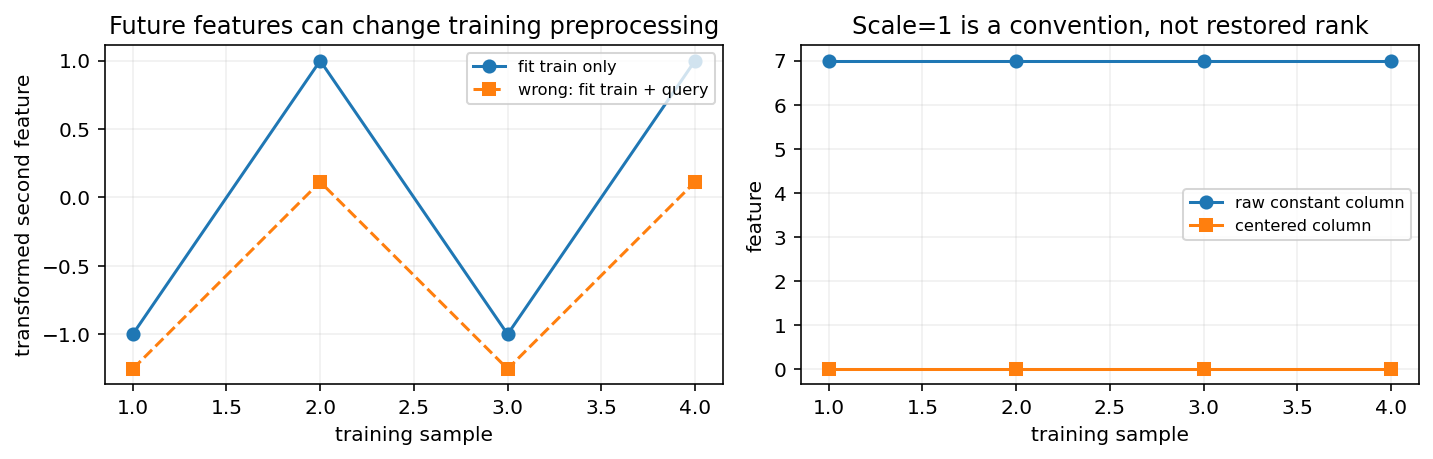

In [11]:
query_z=e.transform(query,scaler)
leaky_scaler=e.fit_scaler(np.vstack([X,query]))
leaky_train=e.transform(X,leaky_scaler)
print("correct query transform:",query_z)
print("reference query predictions:",e.design(query)@np.array(reference["theta"]))
print("incorrect combined-fit mean:",leaky_scaler["mean"])
constant=D["constant"]["X"]
constant_scaler=e.fit_scaler(constant)
constant_z=e.transform(constant,constant_scaler)
print("constant flags:",constant_scaler["zero_variance"],"scales:",constant_scaler["scale"])
fig,axes=plt.subplots(1,2,figsize=(10,3.3))
axes[0].plot(range(1,5),Z[:,1],"o-",label="fit train only")
axes[0].plot(range(1,5),leaky_train[:,1],"s--",label="wrong: fit train + query")
axes[0].set(xlabel="training sample",ylabel="transformed second feature",title="Future features can change training preprocessing")
axes[0].legend(fontsize=8)
axes[1].plot(range(1,5),constant[:,1],"o-",label="raw constant column")
axes[1].plot(range(1,5),constant_z[:,1],"s-",label="centered column")
axes[1].set(xlabel="training sample",ylabel="feature",title="Scale=1 is a convention, not restored rank")
axes[1].legend(fontsize=8)
show(fig)

### 11. 图8 正则化坐标变化
λ=1，截距不惩罚。直接在线性方程中加入已明确的惩罚矩阵，比较原L2、缩放后普通L2以及正确变换惩罚。这里是三个精确目标的演示，不用优化误差混淆惩罚变化。

raw L2: [3.        1.        0.2970297] scaled ordinary L2 mapped back: [3.   1.   0.15] matched weighted: [3.        1.        0.2970297]


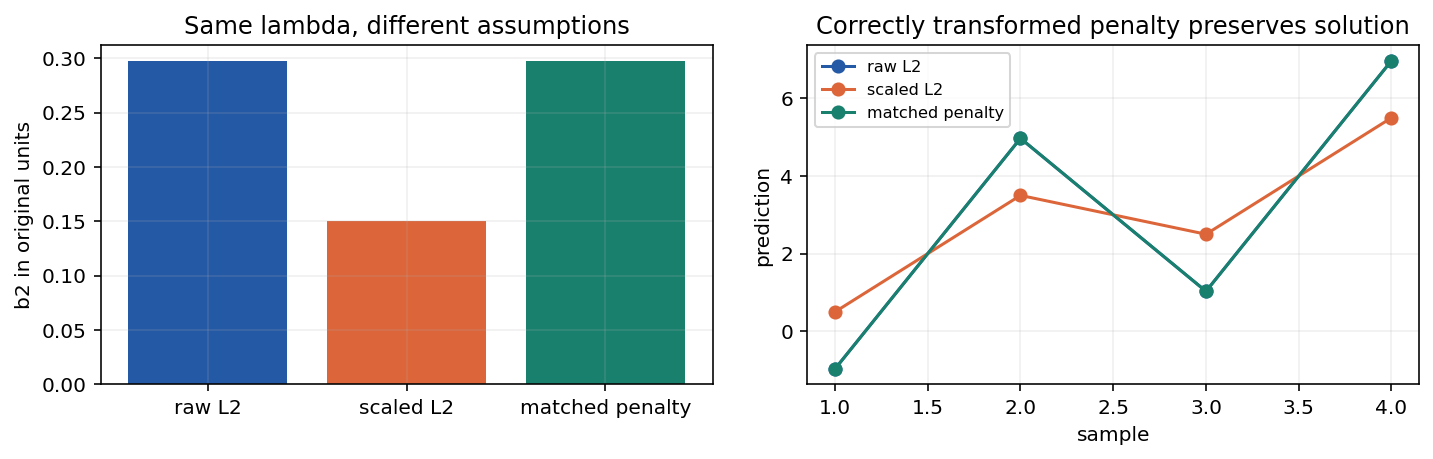

In [12]:
As=e.design(Z)
P=np.diag([0.,1.,1.])
weighted=np.diag([0.,1.,.01])
raw_l2=np.linalg.solve(A.T@A/4+P,A.T@y/4)
scaled_l2=e.to_raw(np.linalg.solve(As.T@As/4+P,As.T@y/4),scaler)
matched_l2=e.to_raw(np.linalg.solve(As.T@As/4+weighted,As.T@y/4),scaler)
print("raw L2:",raw_l2,"scaled ordinary L2 mapped back:",scaled_l2,"matched weighted:",matched_l2)
np.testing.assert_allclose(raw_l2,matched_l2,atol=1e-12)
fig,axes=plt.subplots(1,2,figsize=(10,3.3))
bs=[raw_l2,scaled_l2,matched_l2];labels=["raw L2","scaled L2","matched penalty"]
axes[0].bar(range(3),[b[2] for b in bs],color=colors[:3])
axes[0].set(xticks=range(3),xticklabels=labels,ylabel="b2 in original units",title="Same lambda, different assumptions")
for b,label,color in zip(bs,labels,colors):
    axes[1].plot(range(1,5),A@b,"o-",label=label,color=color)
axes[1].set(xlabel="sample",ylabel="prediction",title="Correctly transformed penalty preserves solution")
axes[1].legend(fontsize=8)
show(fig)

## Checks
### 12. 错误实现与坏输入
下面只在临时值中展示漏除n。异常测试必须真正失败才计数；不使用可被python -O关闭的assert来保护输入。

In [13]:
g=e.loss_gradient(A,y,[0,0,0])["gradient"]
g_duplicate=e.loss_gradient(np.repeat(A,2,axis=0),np.repeat(y,2),[0,0,0])["gradient"]
print("average gradient invariant:",g,g_duplicate)
print("wrong first beta if /n omitted:",-(1/64)*(A.T@(-y)))
np.testing.assert_allclose(g,g_duplicate,atol=0,rtol=0)
def expect_value_error(operation):
    try:
        operation()
    except ValueError:
        return "rejected as intended"
    raise RuntimeError("invalid input was accepted")
print("bool label:",expect_value_error(lambda:e.loss_gradient(A,[True,3.5,1.5,8.5],[0,0,0])))
print("column label:",expect_value_error(lambda:e.loss_gradient(A,y[:,None],[0,0,0])))
print("original nonzero underflow token:",expect_value_error(lambda:e.token("1e-400")))
print("true zero exponent:",e.token("0e-400"))
print("zero budget:",e.trace_path(A,y,{**short_spec,"max_steps":0})["status"])
print("zero step:",e.trace_path(A,y,{**short_spec,"learning_rate":0})["status"])

average gradient invariant: [-3.0, -2.0, -30.0] [-3.0, -2.0, -30.0]
wrong first beta if /n omitted: [0.1875 0.125  1.875 ]
bool label: rejected as intended
column label: rejected as intended
original nonzero underflow token: rejected as intended
true zero exponent: 0.0
zero budget: budget_exhausted
zero step: stagnated_without_tolerance


## Next Steps
观察结果支持的范围很窄但明确：原正交四角例κ=100，训练标准化后κ=1；重新选步长可减少共同精度所需更新。相关例仍约κ=258，常数例仍秩2。标准化不是无条件无害操作，尤其要检查训练信息流、正则化目标与停止指标。

重做练习：用非零均值特征验证完整T和截距映射；再把η设到稳定边界，说明特殊初值例外。一般非二次目标中H会随参数变化，不能直接套用单个H的稳定区间。下一讲继续光滑性与收敛界。

一手来源：[作者优化课件](https://web.stanford.edu/class/ee364a/lectures/unconstrained.pdf)、[NumPy eigvalsh](https://numpy.org/doc/2.3/reference/generated/numpy.linalg.eigvalsh.html)、[NumPy lstsq](https://numpy.org/doc/2.3/reference/generated/numpy.linalg.lstsq.html)、[StandardScaler说明](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)、[数据泄漏说明](https://scikit-learn.org/stable/common_pitfalls.html)。本Notebook的数据、代码、推导和图均独立撰写。